In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv("diabetes_cleaned.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (229781, 22)

First 5 Rows:
   Diabetes_012  HighBP  HighChol  CholCheck  ...  Sex   Age  Education  Income
0           0.0     1.0       1.0        1.0  ...  0.0   9.0        4.0     3.0
1           0.0     0.0       0.0        0.0  ...  0.0   7.0        6.0     1.0
2           0.0     1.0       1.0        1.0  ...  0.0   9.0        4.0     8.0
3           0.0     1.0       0.0        1.0  ...  0.0  11.0        3.0     6.0
4           0.0     1.0       1.0        1.0  ...  0.0  11.0        5.0     4.0

[5 rows x 22 columns]


In [4]:
print("\nMissing Values:")
print(df.isnull().sum().sum())


Missing Values:
0


In [5]:
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]
print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nTarget Distribution:")
print(y.value_counts().sort_index())



Feature Shape: (229781, 21)
Target Shape: (229781,)

Target Distribution:
Diabetes_012
0.0    190055
1.0      4629
2.0     35097
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)



Training Data: (183824, 21)
Testing Data: (45957, 21)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeature scaling completed.")


Feature scaling completed.


In [9]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)
print("\nFinal Training Data:", X_train_final.shape)
print("Validation Data:", X_val.shape)


Final Training Data: (147059, 21)
Validation Data: (36765, 21)


In [10]:
model = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(X_train_final.shape[1],)
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        3,
        activation="softmax"
    )
])

/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,251 (51.76 KB)

 Trainable params: 13,251 (51.76 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - accuracy: 0.8326 - loss: 0.4331 - val_accuracy: 0.8340 - val_loss: 0.4290
Epoch 2/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - accuracy: 0.8329 - loss: 0.4319 - val_accuracy: 0.8345 - val_loss: 0.4289
Epoch 3/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.8335 - loss: 0.4312 - val_accuracy: 0.8344 - val_loss: 0.4280
Epoch 4/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step - accuracy: 0.8338 - loss: 0.4302 - val_accuracy: 0.8353 - val_loss: 0.4312
Epoch 5/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - accuracy: 0.8336 - loss: 0.4297 - val_accuracy: 0.8349 - val_loss: 0.4292
Epoch 6/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step - accuracy: 0.8339 - loss: 0.4293 - val_accuracy: 0.8350 - val_loss: 0.4308


In [17]:
print("\nTraining completed.")
print("Epochs completed:", len(history.history["loss"]))


Training completed.
Epochs completed: 6


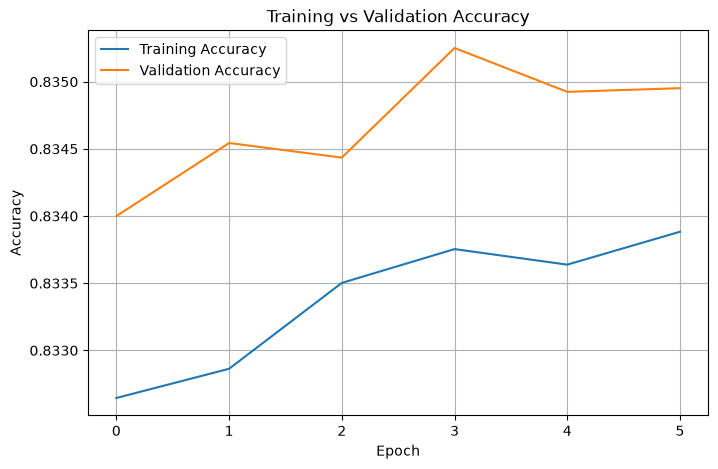

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

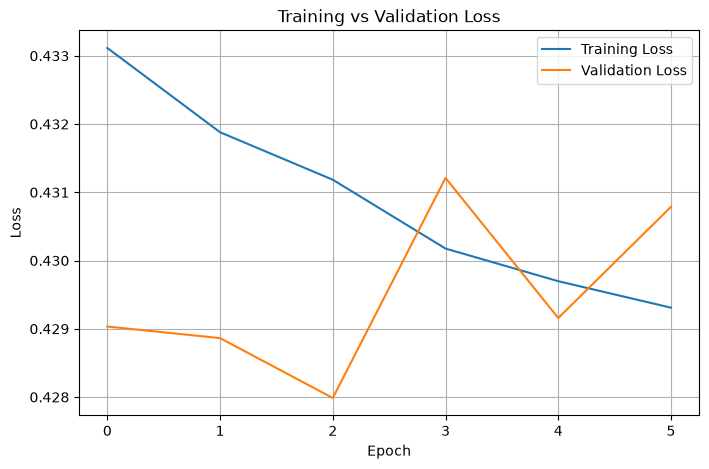

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [21]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("\n===== TEST RESULTS =====")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))


===== TEST RESULTS =====
Test Loss: 0.4241
Test Accuracy: 0.8369


In [22]:
y_probability = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("\nPredictions:")
print(y_pred[:20])


Predictions:
[0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0]


In [23]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print("\n===== DEEP LEARNING MODEL RESULTS =====")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


===== DEEP LEARNING MODEL RESULTS =====
Accuracy : 0.8369
Precision: 0.793
Recall   : 0.8369
F1 Score : 0.7881


In [24]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Diabetes",
            "Prediabetes",
            "Diabetes"
        ],
        zero_division=0
    )
)


              precision    recall  f1-score   support

 No Diabetes       0.85      0.99      0.91     38012
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.62      0.14      0.23      7019

    accuracy                           0.84     45957
   macro avg       0.49      0.38      0.38     45957
weighted avg       0.79      0.84      0.79     45957



In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[37452     0   560]
 [  858     0    68]
 [ 6011     0  1008]]


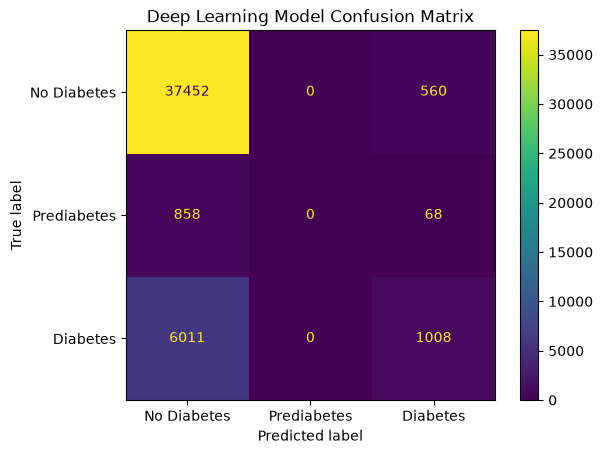

In [26]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Diabetes",
        "Prediabetes",
        "Diabetes"
    ]
)

disp.plot()

plt.title("Deep Learning Model Confusion Matrix")

plt.show()


In [27]:
train_accuracy = history.history["accuracy"][-1]

validation_accuracy = history.history["val_accuracy"][-1]

print("\n===== OVERFITTING CHECK =====")

print(
    "Final Training Accuracy:",
    round(train_accuracy, 4)
)

print(
    "Final Validation Accuracy:",
    round(validation_accuracy, 4)
)

print(
    "Accuracy Difference:",
    round(
        train_accuracy - validation_accuracy,
        4
    )
)



===== OVERFITTING CHECK =====
Final Training Accuracy: 0.8339
Final Validation Accuracy: 0.835
Accuracy Difference: -0.0011


In [28]:
history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "week5_training_history.csv",
    index=False
)

print(
    "\nTraining history saved as "
    "'week5_training_history.csv'"
)



Training history saved as 'week5_training_history.csv'


In [29]:
model.save(
    "week5_diabetes_neural_network.keras"
)

print(
    "Model saved as "
    "'week5_diabetes_neural_network.keras'"
)

Model saved as 'week5_diabetes_neural_network.keras'


In [30]:
print("\n==========================================")
print("       WEEK 5 ANALYSIS COMPLETED")
print("==========================================")

print("Dataset:", "Diabetes Health Indicators")

print("Target:", "Diabetes_012")

print("Classes:")
print("0 = No Diabetes")
print("1 = Prediabetes")
print("2 = Diabetes")

print("\nNeural Network Architecture:")
print("Input")
print("  ↓")
print("Dense 128 + ReLU")
print("  ↓")
print("Dropout 30%")
print("  ↓")
print("Dense 64 + ReLU")
print("  ↓")
print("Dropout 30%")
print("  ↓")
print("Dense 32 + ReLU")
print("  ↓")
print("Dense 3 + Softmax")

print("\nTest Accuracy:",
      round(test_accuracy, 4))

print("Weighted F1 Score:",
      round(f1, 4))

print("==========================================")


       WEEK 5 ANALYSIS COMPLETED
Dataset: Diabetes Health Indicators
Target: Diabetes_012
Classes:
0 = No Diabetes
1 = Prediabetes
2 = Diabetes

Neural Network Architecture:
Input
  ↓
Dense 128 + ReLU
  ↓
Dropout 30%
  ↓
Dense 64 + ReLU
  ↓
Dropout 30%
  ↓
Dense 32 + ReLU
  ↓
Dense 3 + Softmax

Test Accuracy: 0.8369
Weighted F1 Score: 0.7881
